<a href="https://colab.research.google.com/github/aghyaraga-hub/Radyandra-Tugas-Pertemuan-4/blob/main/TAS3_Radyandra%20Prasya_19241891.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#install dependencies

!pip install -q lightgbm shap


<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-1457565130.py:21: SyntaxWarning: invalid escape sequence '\$'
  df[col] = df[col].str.replace('[\$,]', '', regex=True)


✔ Target terdeteksi: Units Sold

=== 5 DATA PERTAMA ===


,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb



=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            4384 non-null   datetime64[ns]
 1   Product Name    4384 non-null   object        
 2   Category        4384 non-null   object        
 3   Units Sold      4384 non-null   int64         
 4   Price           4384 non-null   float64       
 5   Revenue         4384 non-null   float64       
 6   Discount        4384 non-null   float64       
 7   Units Returned  4384 non-null   int64         
 8   Location        4384 non-null   object        
 9   Platform        4384 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 342.6+ KB

=== STATISTIK DESKRIPTIF ===


,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
count,4384,4384,4384,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000,4384,4384
unique,NaN,16,10,NaN,NaN,NaN,NaN,NaN,3,3
top,NaN,Whey Protein,Vitamin,NaN,NaN,NaN,NaN,NaN,Canada,iHerb
freq,NaN,274,822,NaN,NaN,NaN,NaN,NaN,1507,1499
mean,2022-08-18 12:00:00,NaN,NaN,150.200274,34.781229,5226.569446,0.124398,1.531478,NaN,NaN
min,2020-01-06 00:00:00,NaN,NaN,103.000000,10.000000,1284.000000,0.000000,0.000000,NaN,NaN
25%,2021-04-26 00:00:00,NaN,NaN,142.000000,22.597500,3349.372500,0.060000,1.000000,NaN,NaN
50%,2022-08-18 12:00:00,NaN,NaN,150.000000,34.720000,5173.140000,0.120000,1.000000,NaN,NaN
75%,2023-12-11 00:00:00,NaN,NaN,158.000000,46.712500,7009.960000,0.190000,2.000000,NaN,NaN
max,2025-03-31 00:00:00,NaN,NaN,194.000000,59.970000,10761.850000,0.250000,8.000000,NaN,NaN


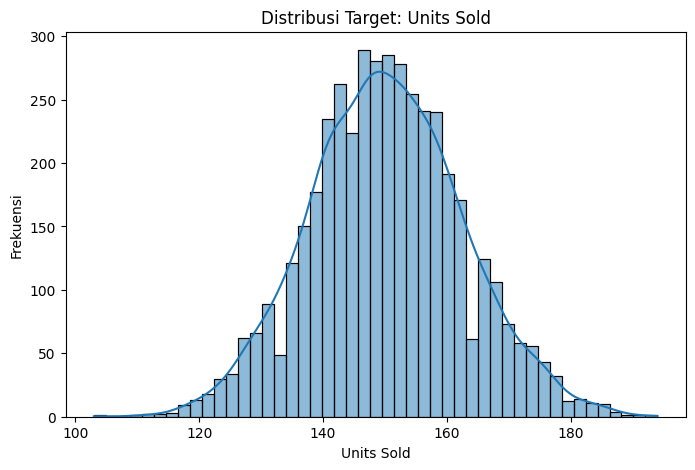


=== Evaluasi Model (Decision Tree Regressor) ===
MAE  = 7.8123
MSE  = 107.3663
RMSE = 10.3618
R² Score = 0.3247


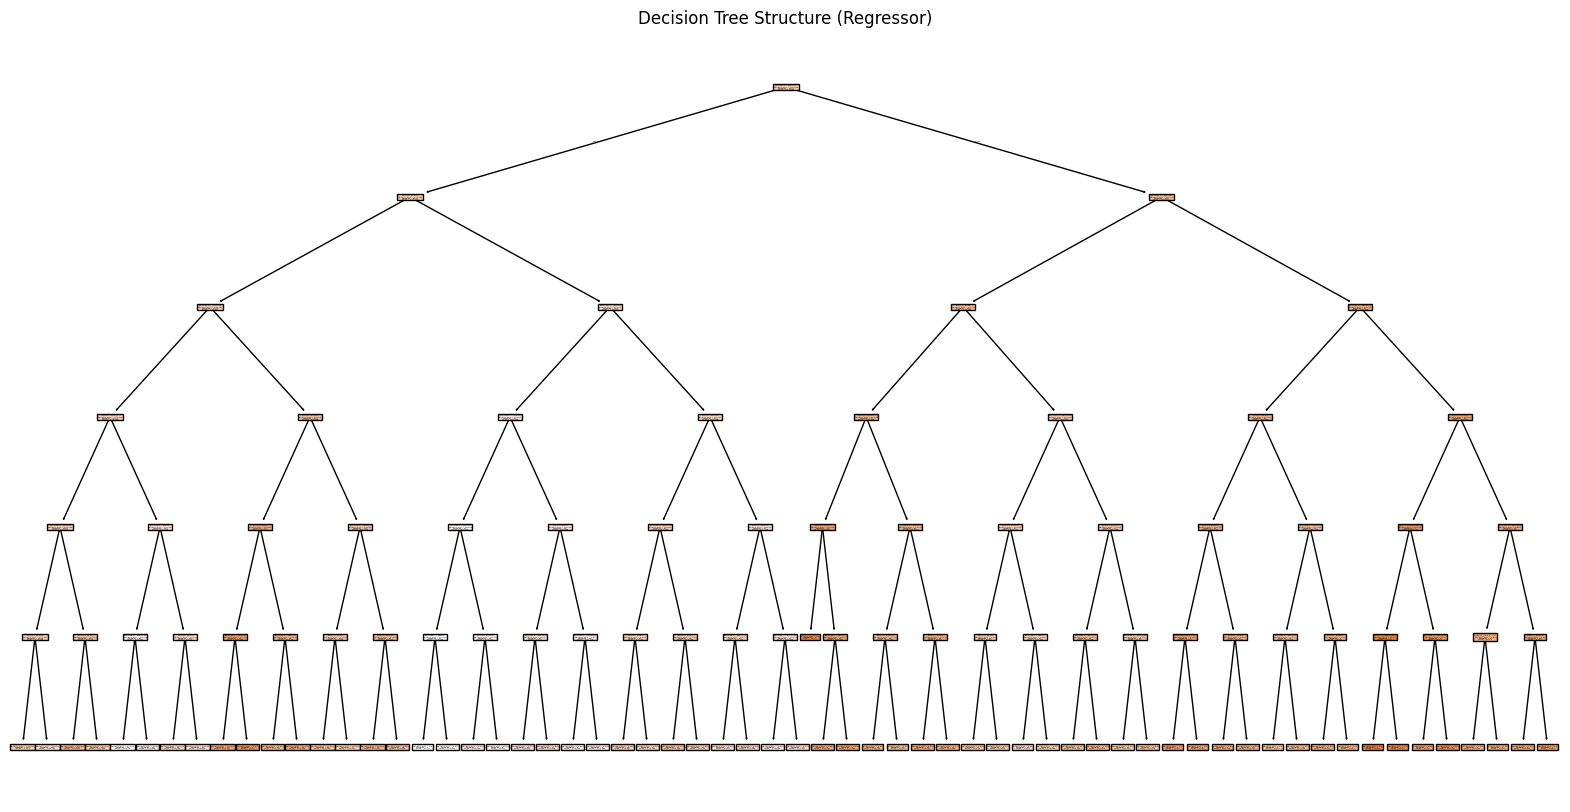

In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
url = "https://raw.githubusercontent.com/aghyaraga-hub/Radyandra-Tugas-Pertemuan-4/main/Supplement_Sales_Weekly_Expanded.csv"
df = pd.read_csv(url)

# Perbaikan TIpe Numerik
num_cols = ['Units Sold', 'Price', 'Revenue', 'Discount', 'Units Returned']

for col in num_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)
        df[col] = df[col].str.replace('[\$,]', '', regex=True)
        df[col] = df[col].str.replace('%', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Konversi Kolom Tanggal
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Deteksi Kolom Target Secara Otomatis
target_candidates = ['units sold', 'units_sold', 'units-sold', 'units', 'sales', 'quantity', 'qty']

cols_normalized = {col: col.lower().replace(" ", "_").replace("-", "_") for col in df.columns}

TARGET = None
for orig_col, norm_col in cols_normalized.items():
    if norm_col in target_candidates:
        TARGET = orig_col
        break

# fallback
if TARGET is None and "Units Sold" in df.columns:
    TARGET = "Units Sold"

if TARGET is None:
    raise ValueError("Kolom target tidak ditemukan. Nama kolom di dataset: " + ", ".join(df.columns))

print(f"✔ Target terdeteksi: {TARGET}")

# Tampilkan Data Awal
print("\n=== 5 DATA PERTAMA ===")
display(df.head())

print("\n=== INFO DATASET ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe(include="all"))

# Distribusi Target (Units Sold)
plt.figure(figsize=(8,5))
sns.histplot(df[TARGET], kde=True)
plt.title("Distribusi Target: Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frekuensi")
plt.show()

# Processing Untuk Model
df_model = df.dropna(subset=[TARGET])  # pastikan target tidak NaN

# Exclude kolom Date → ubah menjadi fitur numerik (optional)
if 'Date' in df_model.columns:
    df_model['Date'] = df_model['Date'].astype('int64') // 10**9  # konversi ke timestamp

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Handle kategori dengan one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model (Decision Tree Regressor)
model = DecisionTreeRegressor(max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Prediksi dan Evaluasi
y_pred = model.predict(X_test)

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("\n=== Evaluasi Model (Decision Tree Regressor) ===")
print(f"MAE  = {MAE:.4f}")
print(f"MSE  = {MSE:.4f}")
print(f"RMSE = {RMSE:.4f}")
print(f"R² Score = {R2:.4f}")

# Visualisasi Pohon Kehidupan
plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns)
plt.title("Decision Tree Structure (Regressor)")
plt.show()

In [ ]:
import pandas as pd

#Load Dataset

url = "https://raw.githubusercontent.com/aghyaraga-hub/Radyandra-Tugas-Pertemuan-4/main/Supplement_Sales_Weekly_Expanded.csv"

df = pd.read_csv(url)

# Target (y) dan Fitur (X)
y = df['Units Sold']
X = df.drop('Units Sold', axis=1)

# Encoding fitur kategorikal
from sklearn.preprocessing import LabelEncoder

label_cols = ['Product Name', 'Category', 'Location', 'Platform']
encoder = LabelEncoder()

for col in label_cols:
    X[col] = encoder.fit_transform(X[col])

# Konversi kolom Date menjadi numerik
X['Date'] = pd.to_datetime(X['Date']).map(lambda x: x.toordinal())

# Split data latih & uji
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Output ukuran data
print(f"\nUkuran Data Latih: {X_train.shape}")
print(f"Ukuran Data Uji: {X_test.shape}")


Ukuran Data Latih: (3068, 9)
Ukuran Data Uji: (1316, 9)


In [ ]:
# Import library (untuk pemodelan regresi)
from sklearn.tree import DecisionTreeRegressor

# Membuat model Decision Tree (pemilihan & pembangunan model)
model = DecisionTreeRegressor(random_state=42)

# Melatih model (membangun model)
model.fit(X_train, y_train)

# Melakukan prediksi dengan data uji (pengujian model)
y_pred = model.predict(X_test)

# Tampilkan hasil prediksi pertama (melihat hasil prediksi)
print("\nPrediksi Pertama:")
print(y_pred[:5])


Prediksi Pertama:
[118. 154. 134. 152. 155.]



Evaluasi Model Decision Tree Regressor:
MAE  : 2.3853
MSE  : 11.9673
RMSE : 3.4594
R²   : 0.9247


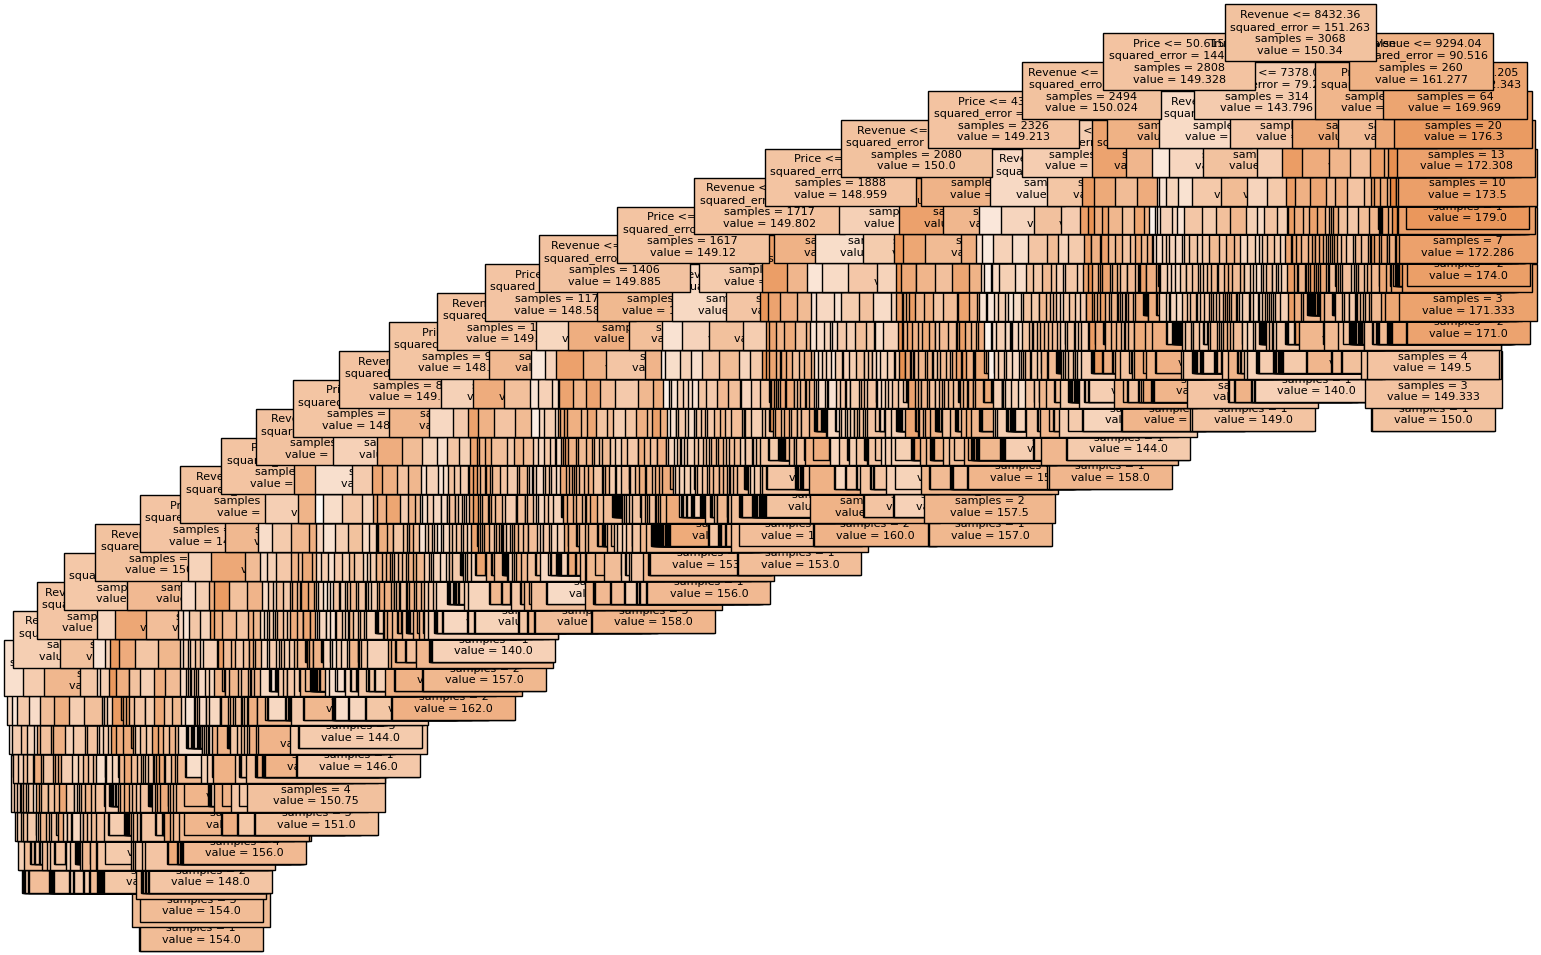

In [ ]:
# Import library untuk evaluasi regresi
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import numpy as np

# Evaluasi Model Regresi

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluasi Model Decision Tree Regressor:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# Visualisasi Pohon Keputusan
plt.figure(figsize=(18, 12))
plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    fontsize=8
)
plt.show()